In [1]:
# Cell 1 — install dan import
!pip install -q imbalanced-learn

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_recall_fscore_support, roc_auc_score)
# Models we'll use later
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# imbalanced-learn
import imblearn
from imblearn.over_sampling import SMOTE

# Reproducible seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# Display options
pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')

print("Environment siap. Numpy:", np.__version__, "Pandas:", pd.__version__)

Environment siap. Numpy: 2.0.2 Pandas: 2.2.2


In [2]:
# Cell 2 — mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/data-bank.csv'
df = pd.read_csv(file_path)
print("Data dimuat dari Drive. Shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data dimuat dari Drive. Shape: (6819, 96)


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,1.256969e-04,0.0,0.458143,0.000725,0.0,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820926e-04,1.165007e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,2.897851e-04,0.0,0.461867,0.000647,0.0,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025484,0.0068

In [3]:
# Cell 3 — pemeriksaan awal
print("Shape:", df.shape)
print("\nColumns:")
for i, c in enumerate(df.columns):
    print(i+1, c)

print("\nInfo singkat:")
display(df.info())

print("\nRingkasan statistik (numerik):")
display(df.describe().T)

print("\nJumlah missing per kolom:")
display(df.isnull().sum().sort_values(ascending=False).head(20))

Shape: (6819, 96)

Columns:
1 Bankrupt?
2  ROA(C) before interest and depreciation before interest
3  ROA(A) before interest and % after tax
4  ROA(B) before interest and depreciation after tax
5  Operating Gross Margin
6  Realized Sales Gross Margin
7  Operating Profit Rate
8  Pre-tax net Interest Rate
9  After-tax net Interest Rate
10  Non-industry income and expenditure/revenue
11  Continuous interest rate (after tax)
12  Operating Expense Rate
13  Research and development expense rate
14  Cash flow rate
15  Interest-bearing debt interest rate
16  Tax rate (A)
17  Net Value Per Share (B)
18  Net Value Per Share (A)
19  Net Value Per Share (C)
20  Persistent EPS in the Last Four Seasons
21  Cash Flow Per Share
22  Revenue Per Share (Yuan ¥)
23  Operating Profit Per Share (Yuan ¥)
24  Per Share Net profit before tax (Yuan ¥)
25  Realized Sales Gross Profit Growth Rate
26  Operating Profit Growth Rate
27  After-tax Net Profit Growth Rate
28  Regular Net Profit Growth Rate
29  Continuou

None


Ringkasan statistik (numerik):


,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0



Jumlah missing per kolom:


,0
Bankrupt?,0
ROA(C) before interest and depreciation before interest,0
ROA(A) before interest and % after tax,0
ROA(B) before interest and depreciation after tax,0
Operating Gross Margin,0
Realized Sales Gross Margin,0
Operating Profit Rate,0
Pre-tax net Interest Rate,0
After-tax net Interest Rate,0
Non-industry income and expenditure/revenue,0


In [4]:
# Cell 4 — deteksi nama kolom target
candidates = [c for c in df.columns if any(k in c.lower() for k in ['bankrupt','bank','bankcupt','bankcrupt','bankruptcy'])]
print("Kolom yang mengandung kata 'bank'/'bankrupt' (kemungkinan target):")
print(candidates)

# Periksa value counts untuk kandidat
for c in candidates:
    print("\n=== Value counts untuk:", c, "===")
    try:
        print(df[c].value_counts(dropna=False).head(20))
    except Exception as e:
        print("Gagal membaca value counts:", e)

Kolom yang mengandung kata 'bank'/'bankrupt' (kemungkinan target):
['Bankrupt?']

=== Value counts untuk: Bankrupt? ===
Bankrupt?
0    6599
1     220
Name: count, dtype: int64


In [5]:
# Cell 5 — cek class balance
TARGET_COL = 'Bankrupt?'
if TARGET_COL not in df.columns:
    raise ValueError(f"Kolom target '{TARGET_COL}' tidak ada. Ganti nama kolom pada kode.")

print("Distribusi kelas:")
display(df[TARGET_COL].value_counts())
print("\nProporsi kelas:")
display(df[TARGET_COL].value_counts(normalize=True))

Distribusi kelas:


,count
Bankrupt?,
0,6599
1,220



Proporsi kelas:


,proportion
Bankrupt?,
0,0.967737
1,0.032263


In [6]:
# Cell 6A — statistik per kelas target
grouped_stats = df.groupby('Bankrupt?').mean().T
grouped_stats['difference'] = grouped_stats[1] - grouped_stats[0]
grouped_stats_sorted = grouped_stats['difference'].abs().sort_values(ascending=False).head(10)
print("10 fitur dengan perbedaan rata-rata terbesar antara bank bangkrut vs tidak:\n")
display(grouped_stats.loc[grouped_stats_sorted.index])

10 fitur dengan perbedaan rata-rata terbesar antara bank bangkrut vs tidak:



Bankrupt?,0,1,difference
Fixed Assets Turnover Frequency,9.756574e+08,1.996603e+09,1.020945e+09
Total Asset Growth Rate,5.531603e+09,4.803017e+09,-7.285860e+08
Quick Asset Turnover Rate,2.147829e+09,2.640836e+09,4.930069e+08
Research and development expense rate,1.961923e+09,1.605623e+09,-3.562993e+08
Cash Turnover Rate,2.481653e+09,2.181733e+09,-2.999205e+08
Cash/Current Liability,2.989953e+07,2.549409e+08,2.250414e+08
Current Asset Turnover Rate,1.189712e+09,1.380154e+09,1.904424e+08
Operating Expense Rate,1.998943e+09,1.887486e+09,-1.114569e+08
Total assets to GNP price,1.621670e+07,9.100000e+07,7.478330e+07
Net Value Growth Rate,2.045765e+05,4.240909e+07,4.220451e+07


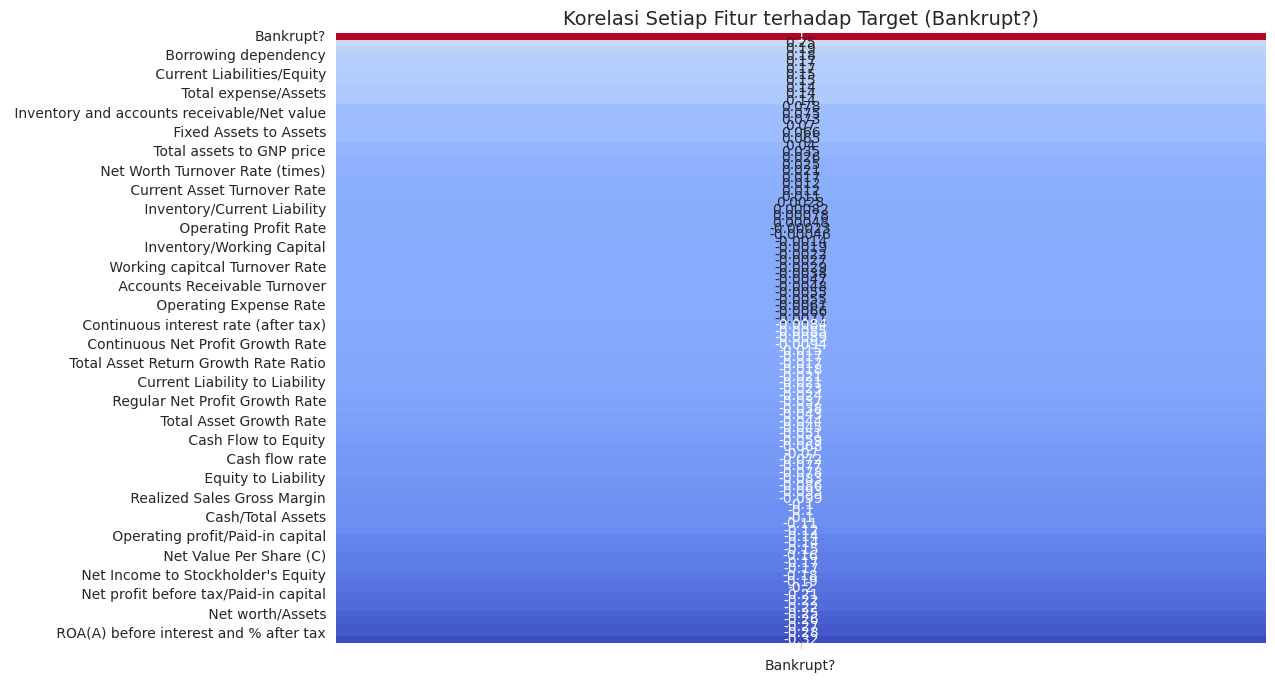

In [7]:
# Cell 6B — heatmap korelasi
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr[['Bankrupt?']].sort_values(by='Bankrupt?', ascending=False),
            cmap='coolwarm', annot=True, cbar=False)
plt.title('Korelasi Setiap Fitur terhadap Target (Bankrupt?)', fontsize=14)
plt.show()

Fitur yang digunakan untuk boxplot: [' Net Income to Total Assets', ' ROA(A) before interest and % after tax', ' ROA(B) before interest and depreciation after tax']


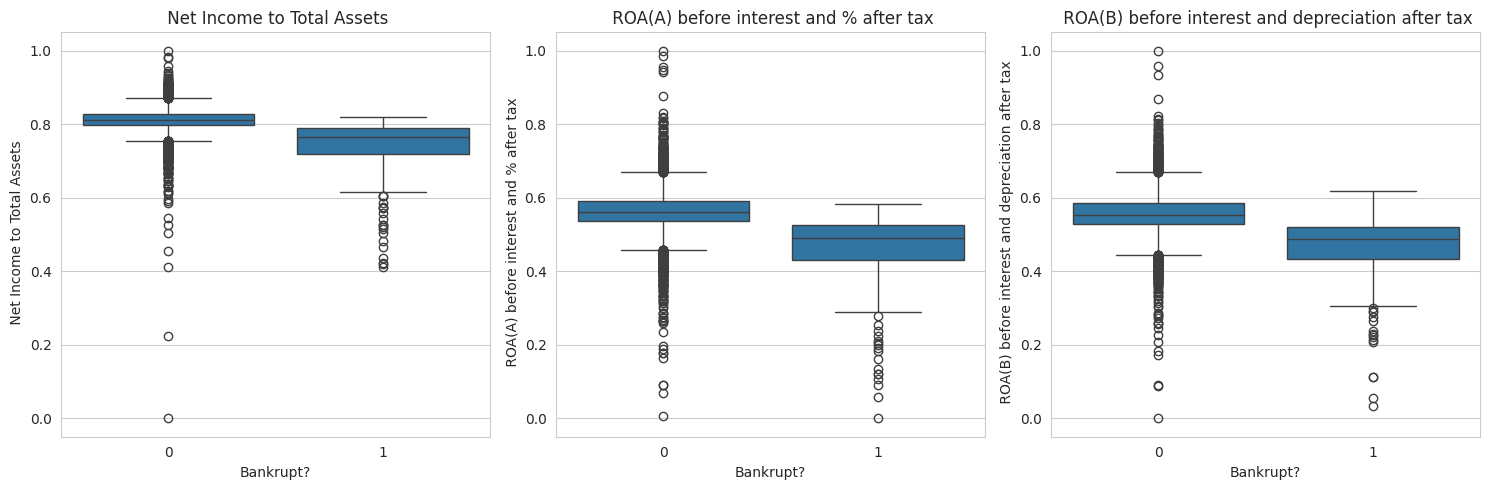

In [8]:
# Cell 6C — boxplot fitur terhadap status Bankrupt
top_features = corr['Bankrupt?'].abs().sort_values(ascending=False).index[1:4]
print("Fitur yang digunakan untuk boxplot:", list(top_features))

plt.figure(figsize=(15,5))
for i, feat in enumerate(top_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='Bankrupt?', y=feat, data=df)
    plt.title(feat)
plt.tight_layout()
plt.show()

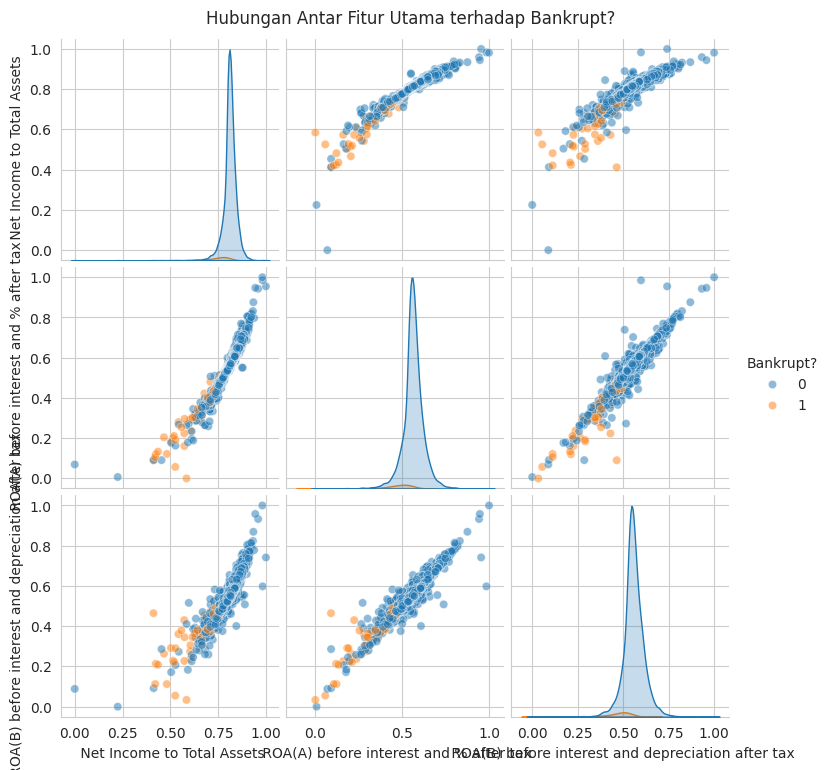

In [9]:
# Cell 6D — pairplot sederhana
sns.pairplot(df, vars=top_features, hue='Bankrupt?', diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Hubungan Antar Fitur Utama terhadap Bankrupt?', y=1.02)
plt.show()

In [10]:
# Cell 7A — Split data
TARGET_COL = 'Bankrupt?'

# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Ukuran data:")
print("Train set:", X_train.shape, "Target train:", y_train.shape)
print("Test set :", X_test.shape, "Target test :", y_test.shape)
print("\nDistribusi kelas pada train set:")
display(y_train.value_counts(normalize=True))

Ukuran data:
Train set: (5455, 95) Target train: (5455,)
Test set : (1364, 95) Target test : (1364,)

Distribusi kelas pada train set:


,proportion
Bankrupt?,
0,0.967736
1,0.032264


In [11]:
# Cell 7B — Menangani imbalance dengan SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Setelah SMOTE:")
print(y_train_res.value_counts())
print("\nProporsi kelas setelah SMOTE:")
print(y_train_res.value_counts(normalize=True))

Setelah SMOTE:
Bankrupt?
0    5279
1    5279
Name: count, dtype: int64

Proporsi kelas setelah SMOTE:
Bankrupt?
0    0.5
1    0.5
Name: proportion, dtype: float64


In [12]:
# Cell 7C — Standardisasi fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print("Scaling selesai.")
print("Contoh hasil scaling (5 fitur pertama):")
pd.DataFrame(X_train_scaled, columns=X.columns).head()

Scaling selesai.
Contoh hasil scaling (5 fitur pertama):


,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,0.395853,0.433620,0.428451,-0.302425,-0.303047,0.020357,0.050608,0.052179,0.037411,0.048700,1.581085,-0.702158,0.163308,-0.125645,0.954732,0.869275,0.868224,0.864058,0.350355,0.060132,-0.015895,-0.020109,0.322078,-0.012981,0.091850,0.198144,0.195563,0.449580,0.794399,-0.009733,0.228566,0.207822,0.005511,-0.054832,-0.007076,-0.050307,-1.534809,1.534809,-0.109889,-0.359028,-0.078214,-0.033818,0.301401,-0.420887,0.201913,-0.031808,-0.029266,-0.670015,-0.511109,-0.375702,-0.009733,0.017062,-0.045549,0.064542,-1.080940,-0.988044,-0.690754,-0.016825,-0.148121,-1.226164,0.204967,0.009905,-0.101134,0.328469,0.079845,-0.260764,-0.098014,0.404646,0.004105,-0.675828,2.224226,0.434215,-0.019039,-0.657783,-0.011844,-0.044184,0.328469,-0.260764,-0.258831,-0.107440,-0.082840,0.172135,0.037439,-0.536835,-0.021767,0.493502,-0.08143,0.000392,-0.302486,0.188344,-0.278683,-0.081354,0.006260,0.0,0.746057
1,0.925641,0.873264,0.778738,-0.251651,-0.260678,0.024766,0.051911,0.052722,0.029270,0.049289,0.532613,-0.702158,0.086464,-0.125645,1.418393,0.698068,0.697914,0.693896,1.154775,0.726341,-0.015895,1.483364,1.241283,-0.026556,0.088385,0.135461,0.132973,0.010389,-1.741142,-0.009733,0.194965,0.313325,0.006385,-0.054832,0.004860,-0.050307,0.174426,-0.174426,-0.095367,-0.209300,-0.041863,1.497075,1.289634,0.422879,2.966165,-0.031808,-0.029266,-0.

In [13]:
# Cell 7D — Ringkasan akhir
print("Train shape (setelah SMOTE & scaling):", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)
print("\nTarget train balance:\n", y_train_res.value_counts(normalize=True))
print("\nTarget test balance:\n", y_test.value_counts(normalize=True))

Train shape (setelah SMOTE & scaling): (10558, 95)
Test shape: (1364, 95)

Target train balance:
 Bankrupt?
0    0.5
1    0.5
Name: proportion, dtype: float64

Target test balance:
 Bankrupt?
0    0.967742
1    0.032258
Name: proportion, dtype: float64


In [14]:
# Cell 8A — Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=RANDOM_STATE,
    max_depth=6,
    class_weight='balanced'
)
dt_model.fit(X_train_scaled, y_train_res)
y_pred_dt = dt_model.predict(X_test_scaled)

print("=== Decision Tree ===")
print(classification_report(y_test, y_pred_dt))

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      1320
           1       0.17      0.66      0.27        44

    accuracy                           0.89      1364
   macro avg       0.58      0.78      0.61      1364
weighted avg       0.96      0.89      0.92      1364



In [15]:
# Cell 8B — Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)
rf_model.fit(X_train_scaled, y_train_res)
y_pred_rf = rf_model.predict(X_test_scaled)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.40      0.61      0.49        44

    accuracy                           0.96      1364
   macro avg       0.69      0.79      0.73      1364
weighted avg       0.97      0.96      0.96      1364



In [16]:
# Cell 8C — ANN (Multi-Layer Perceptron)
ann_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=300,
    random_state=RANDOM_STATE
)
ann_model.fit(X_train_scaled, y_train_res)
y_pred_ann = ann_model.predict(X_test_scaled)

print("=== Artificial Neural Network (MLP) ===")
print(classification_report(y_test, y_pred_ann))

=== Artificial Neural Network (MLP) ===
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1320
           1       0.35      0.41      0.38        44

    accuracy                           0.96      1364
   macro avg       0.66      0.69      0.68      1364
weighted avg       0.96      0.96      0.96      1364



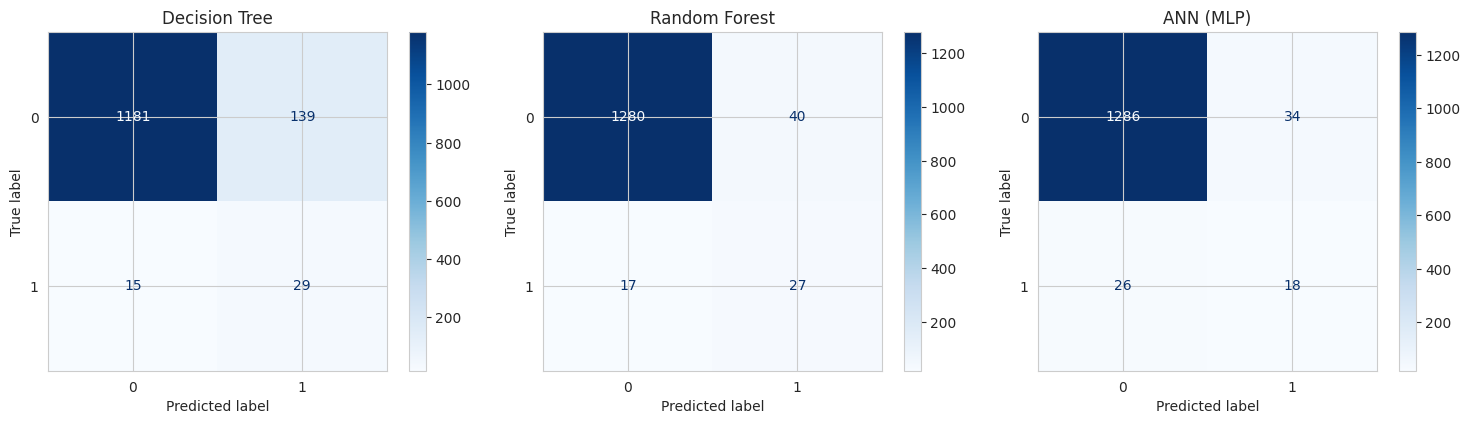

In [17]:
# Cell 8D — confusion matrix untuk semua model
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Decision Tree": (dt_model, y_pred_dt),
    "Random Forest": (rf_model, y_pred_rf),
    "ANN (MLP)": (ann_model, y_pred_ann)
}

plt.figure(figsize=(15,4))
for i, (name, (model, preds)) in enumerate(models.items(), 1):
    plt.subplot(1, 3, i)
    ConfusionMatrixDisplay.from_predictions(y_test, preds, ax=plt.gca(), cmap='Blues')
    plt.title(name)
plt.tight_layout()
plt.show()

In [18]:
# Cell 8E — Ringkasan metrik tiap model
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(y_true, y_pred, name):
    return {
        "Model": name,
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_pred)
    }

results = []
results.append(evaluate_model(y_test, y_pred_dt, "Decision Tree"))
results.append(evaluate_model(y_test, y_pred_rf, "Random Forest"))
results.append(evaluate_model(y_test, y_pred_ann, "ANN (MLP)"))

results_df = pd.DataFrame(results)
print("=== Perbandingan Performa Model ===")
display(results_df.sort_values(by="F1-score", ascending=False))

=== Perbandingan Performa Model ===


,Model,Precision,Recall,F1-score,ROC-AUC
1,Random Forest,0.402985,0.613636,0.486486,0.791667
2,ANN (MLP),0.346154,0.409091,0.375000,0.691667
0,Decision Tree,0.172619,0.659091,0.273585,0.776894


=== Evaluasi Model Terbaik ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1320
           1       0.40      0.61      0.49        44

    accuracy                           0.96      1364
   macro avg       0.69      0.79      0.73      1364
weighted avg       0.97      0.96      0.96      1364



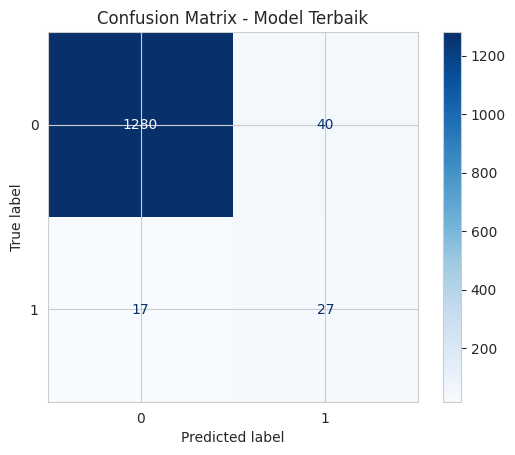

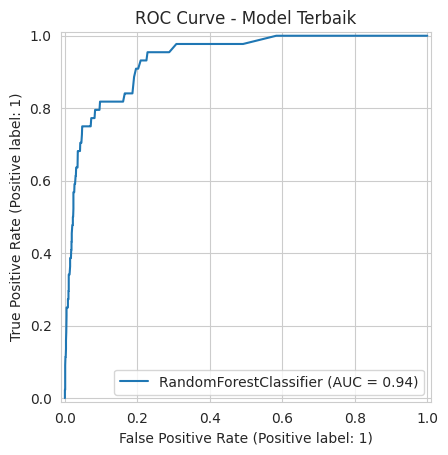

In [19]:
# Cell 9A — Evaluasi mendetail model terbaik
best_model = rf_model
y_pred_best = y_pred_rf

print("=== Evaluasi Model Terbaik ===")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, cmap='Blues')
plt.title("Confusion Matrix - Model Terbaik")
plt.show()

# ROC-AUC
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(best_model, X_test_scaled, y_test)
plt.title("ROC Curve - Model Terbaik")
plt.show()

/tmp/ipython-input-3500061197.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")


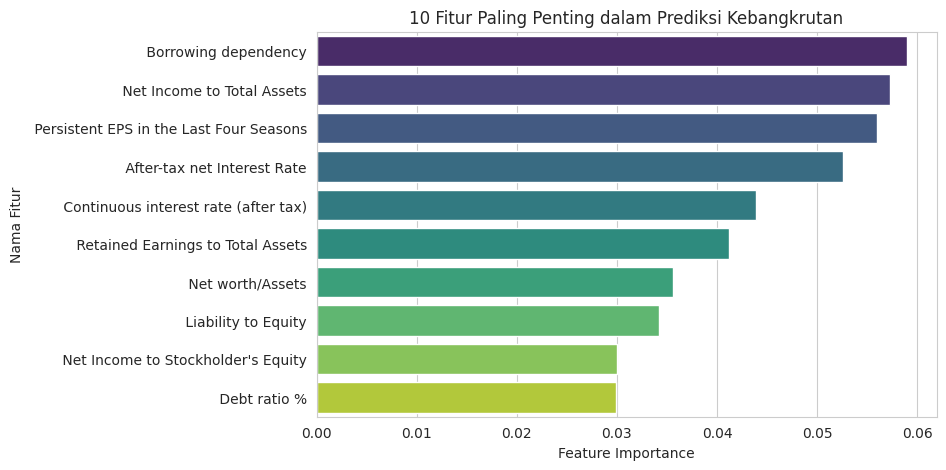


=== 5 Variabel Paling Mempengaruhi Kebangkrutan Bank ===


,0
Borrowing dependency,0.058975
Net Income to Total Assets,0.057257
Persistent EPS in the Last Four Seasons,0.055960
After-tax net Interest Rate,0.052554
Continuous interest rate (after tax),0.043930


In [20]:
# Cell 9B — Feature Importance (untuk Random Forest)
importances = pd.Series(best_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("10 Fitur Paling Penting dalam Prediksi Kebangkrutan")
plt.xlabel("Feature Importance")
plt.ylabel("Nama Fitur")
plt.show()

print("\n=== 5 Variabel Paling Mempengaruhi Kebangkrutan Bank ===")
display(top_features.head(5))

In [21]:
# Cell 9C — Simpan hasil penting
important_vars = list(top_features.head(5).index)
print("Lima variabel paling berpengaruh:")
for i, v in enumerate(important_vars, 1):
    print(f"{i}. {v}")

Lima variabel paling berpengaruh:
1.  Borrowing dependency
2.  Net Income to Total Assets
3.  Persistent EPS in the Last Four Seasons
4.  After-tax net Interest Rate
5.  Continuous interest rate (after tax)


In [22]:
# Cell 9D — Ringkasan akhir
best_model_name = "Random Forest"

print(f"=== Ringkasan Model {best_model_name} ===")
print(f"- Akurasi model pada data test: {best_model.score(X_test_scaled, y_test):.4f}")
print(f"- Recall kelas 'bangkrut' : {recall_score(y_test, y_pred_best):.4f}")
print(f"- F1-score kelas 'bangkrut': {f1_score(y_test, y_pred_best):.4f}")
print(f"- ROC-AUC: {roc_auc_score(y_test, y_pred_best):.4f}")
print("\nFitur paling berpengaruh:")
for i, v in enumerate(important_vars, 1):
    print(f"{i}. {v}")

=== Ringkasan Model Random Forest ===
- Akurasi model pada data test: 0.9582
- Recall kelas 'bangkrut' : 0.6136
- F1-score kelas 'bangkrut': 0.4865
- ROC-AUC: 0.7917

Fitur paling berpengaruh:
1.  Borrowing dependency
2.  Net Income to Total Assets
3.  Persistent EPS in the Last Four Seasons
4.  After-tax net Interest Rate
5.  Continuous interest rate (after tax)
